# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks X: MobileNet

<br/>
Jiří Fejlek

2026-05-19
<br/>


In this small project, we will implement a series of efficient convolutional neural networks for mobile devices:  MobileNet V1, V2, and V3 [[1](#1), [2](#2), [3](#3)]. The common element of all of these networks is the use of *depthwise separable convolutions*, which are convolution blocks that replace standard convolutions with *depthwise* convolution (grouped convolution) and *pointwise* convolution (1x1 convolution) [[1](#1)]. As we discussed in the earlier project, the main benefit of using grouped convolution instead of standard convolution is a much smaller model size, which is important for devices with limited memory.


## Table of Contents

- [MobileNet](#mobilenet)
- [MobileNet-V2](#mobilenet2)
- [MobileNet-V3](#mobilenet3)
    - [Squeeze-and-Excitation](#squeeze)
    - [MobileNet-V3](#mobilenet3_2)
- [References](#references)


## MobileNet <a class="anchor" id="mobilenet"></a>

Let us start with the original MobileNet from 2017 [[1](#1)]. We first repeat the common functions from our previous projects.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

As we mentioned in the introduction, MobileNet is based on depthwise separable convolution blocks, which combine a 3x3 grouped convolution layer with a 1x1 convolution layer. The group convolution here has the number of groups equal to the number of channels (i.e., there is one 3x3 kernel per channel). Next, a 1x1 layer is used to combine the results from the grouped convolutions. Subsequently, this approach mimics the standard convolution, which performs both operations in a single step: separate 3x3 convolutions are applied to each channel (i.e., a group convolution), and the results are then added (which is equivalent to a 1x1 convolution with a kernel of 1). The difference is that depthwise separable convolution has a much smaller number of parameters, because there is only one 3x3 kernel for each input channel (instead of equal to the number of output channels) [[1](#1)].

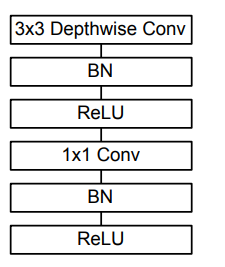

The MobileNet architecture is as follows [[1](#1)].

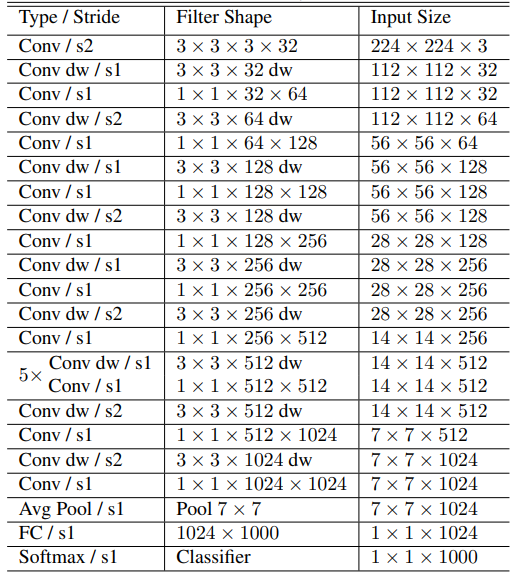

Let us implement it.

In [6]:
class Depthwise_convolution(nn.Module):

    def __init__(self, num_channels, stride):
        super().__init__()

        self.net_stack = nn.LazyConv2d(num_channels, kernel_size=3, stride = stride, padding = 1, groups = num_channels) 
            
    def forward(self, x):
        output = self.net_stack(x)
        return output

In [7]:
class MobileNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            Depthwise_convolution(32, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            
            Depthwise_convolution(64, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(128, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            
            Depthwise_convolution(128, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(128, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(128, stride = 2),
            nn.LazyConv2d(256, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            
            Depthwise_convolution(256, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(256, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(512, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            
            Depthwise_convolution(512, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(512, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(512, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(512, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(512, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(512, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(512, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(512, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(512, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(512, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Depthwise_convolution(512, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(1024, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            
            Depthwise_convolution(1024, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(1024, kernel_size=1),  nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(),
            nn.LazyLinear(num_classes)
        )
        

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [8]:
layer_summary(MobileNet(10),(1, 1, 128, 128))

Conv2d output shape:	 torch.Size([1, 32, 64, 64])
BatchNorm2d output shape:	 torch.Size([1, 32, 64, 64])
ReLU output shape:	 torch.Size([1, 32, 64, 64])
Depthwise_convolution output shape:	 torch.Size([1, 32, 64, 64])
BatchNorm2d output shape:	 torch.Size([1, 32, 64, 64])
ReLU output shape:	 torch.Size([1, 32, 64, 64])
Conv2d output shape:	 torch.Size([1, 64, 64, 64])
BatchNorm2d output shape:	 torch.Size([1, 64, 64, 64])
ReLU output shape:	 torch.Size([1, 64, 64, 64])
Depthwise_convolution output shape:	 torch.Size([1, 64, 32, 32])
BatchNorm2d output shape:	 torch.Size([1, 64, 32, 32])
ReLU output shape:	 torch.Size([1, 64, 32, 32])
Conv2d output shape:	 torch.Size([1, 128, 32, 32])
BatchNorm2d output shape:	 torch.Size([1, 128, 32, 32])
ReLU output shape:	 torch.Size([1, 128, 32, 32])
Depthwise_convolution output shape:	 torch.Size([1, 128, 32, 32])
BatchNorm2d output shape:	 torch.Size([1, 128, 32, 32])
ReLU output shape:	 torch.Size([1, 128, 32, 32])
Conv2d output shape:	 torch.Siz

Let us train MobileNet on the Fashion-MNIST dataset [[4](#4)].

In [9]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [128, 128], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([128, 128]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# mobilenet initialization
MobileNet_cuda = MobileNet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
MobileNet_cuda(x);
MobileNet_cuda.apply(init_weights_he);

In [10]:
sum(p.numel() for p in MobileNet_cuda.parameters() if p.requires_grad)

3227338

To give this number some context,  Xception from our last project had over 20 million parameters, and the popular ResNet-101 has over 40 million parameters. 

In [11]:
optim_SGD_cuda =  torch.optim.SGD(MobileNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, MobileNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1780.2596554756165


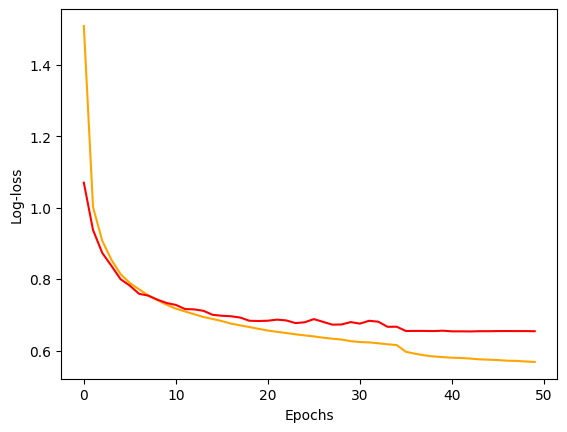

In [12]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

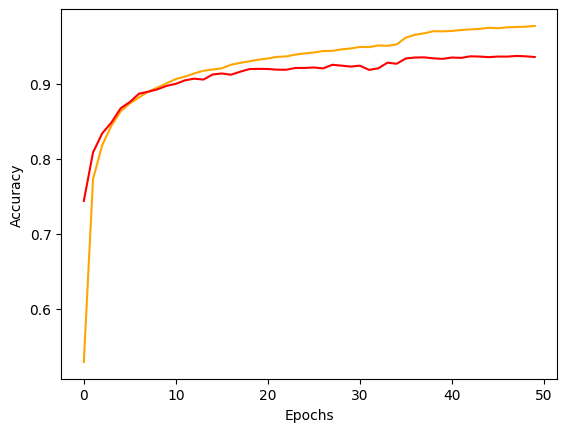

In [13]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

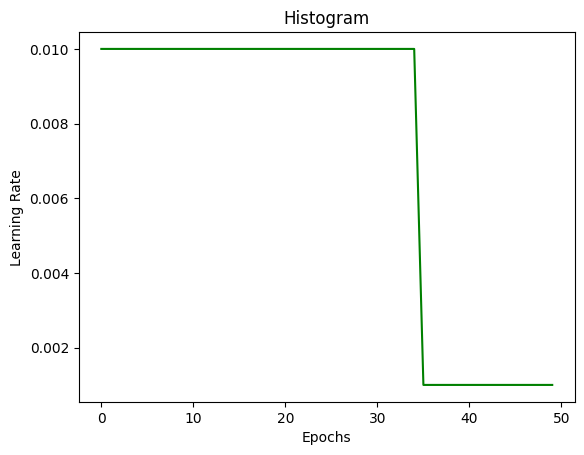

In [14]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [15]:
accu_epochs_train[49]

0.9770333170890808

In [16]:
accu_epochs_test[49]

0.9355999827384949

In [17]:
accu_epochs_test.max()

0.9369999766349792

We have achieved reasonable accuracy, comparable to other CNN architectures. As usual, the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html) is next.

In [18]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[128,128], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Resize([128, 128]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# mobilenet initialization
MobileNet_cuda = MobileNet(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
MobileNet_cuda(x);
MobileNet_cuda.apply(init_weights_he);

In [19]:
optim_SGD_cuda =  torch.optim.SGD(MobileNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, MobileNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

7354.424082994461


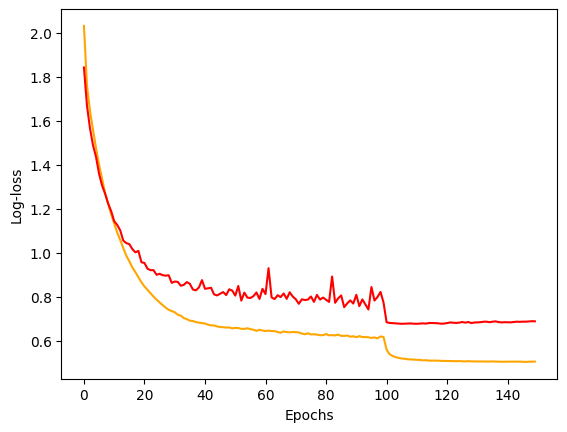

In [20]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

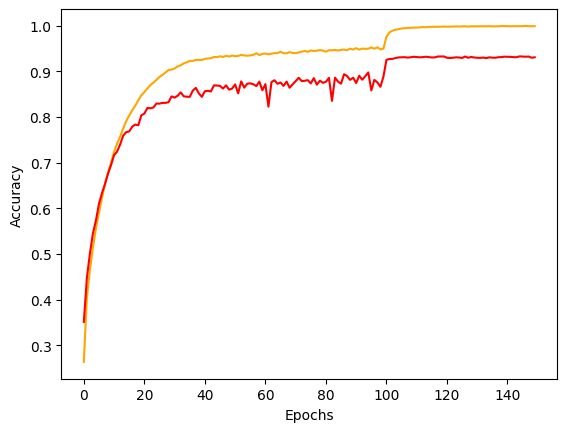

In [21]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

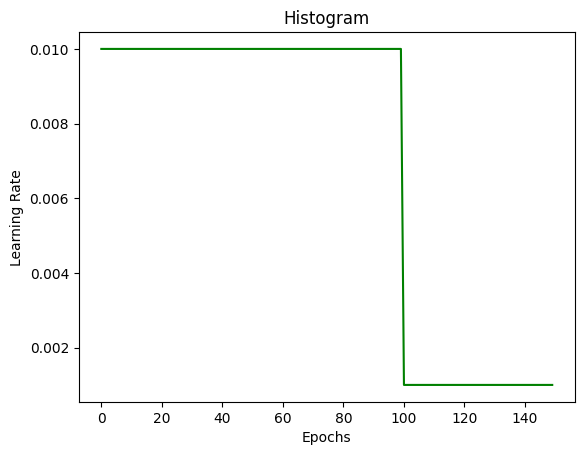

In [22]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [23]:
accu_epochs_train[149]

0.9985599517822266

In [24]:
accu_epochs_test[149]

0.9304999709129333

In [25]:
accu_epochs_test.max()

0.9325000047683716

Again, we have attained a pretty decent performance.

## MobileNet-V2 <a class="anchor" id="mobilenet2"></a>

MobileNet-V2 [[2](#2)], from 2018, updates the MobileNet architecture by adding residual connections that were missing in the original design. MobileNet-V2 consists of two main blocks: *inverted residual blocks* and *linear bottleneck blocks*. 

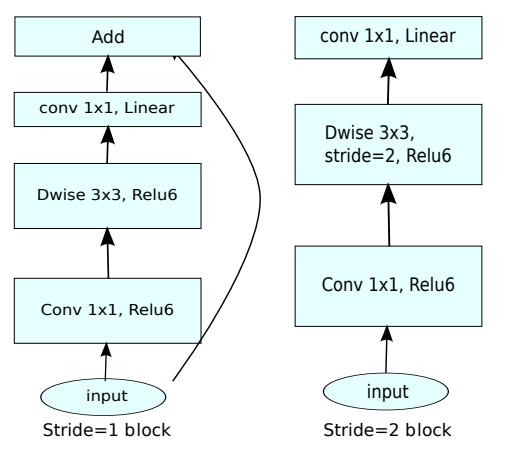

The inverted residual block is a depthwise separable convolution block with a residual connection. The block is called *inverted*, since it follows the design of expanding the number of channels first (given by the *expansion_factor* parameter), then reducing it to the output value, unlike earlier blocks such as Inception blocks or ResNet bottleneck blocks, which first reduce the number of channels and then upscale [[2](#2)].

The architecture also uses separable convolution blocks without residual connections (so-called linear bottlenecks) in parts of the network when the number of input channels differs from the number of output channels [[2](#2)].

Lastly, we note that MobileNet-V2 uses the ReLU6 activation function (ReLU with an upper bound of 6) instead of ReLU, as bounding the activation function makes the network more memory-efficient (allowing low-precision inference) [[2](#2)]. 

In [26]:
class Inverted_residual_block(nn.Module):
    
    def __init__(self, num_channels, expansion_factor): # in_channels == out_channels and stride = 1 for an inverted residual block!
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.Conv2d(num_channels, expansion_factor*num_channels, kernel_size=1),  nn.LazyBatchNorm2d(), torch.nn.ReLU6(),
            Depthwise_convolution(expansion_factor*num_channels, stride = 1), nn.LazyBatchNorm2d(), torch.nn.ReLU6(),
            nn.LazyConv2d(num_channels, kernel_size=1), nn.LazyBatchNorm2d())

    def forward(self, x):
        y = self.net_stack(x)
        return y + x

In [27]:
class Linear_bottleneck(nn.Module):
    
    def __init__(self, in_channels, out_channels, stride, expansion_factor):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.Conv2d(in_channels, out_channels*expansion_factor, kernel_size=1),  nn.LazyBatchNorm2d(), torch.nn.ReLU6(),
            Depthwise_convolution(out_channels*expansion_factor, stride = stride), nn.LazyBatchNorm2d(), torch.nn.ReLU6(),
            nn.LazyConv2d(out_channels, kernel_size=1), nn.LazyBatchNorm2d())

    def forward(self, x):
        y = self.net_stack(x)
        return y

Overall, MobilNet-V2 has the following architecture [[2](#2)]. 

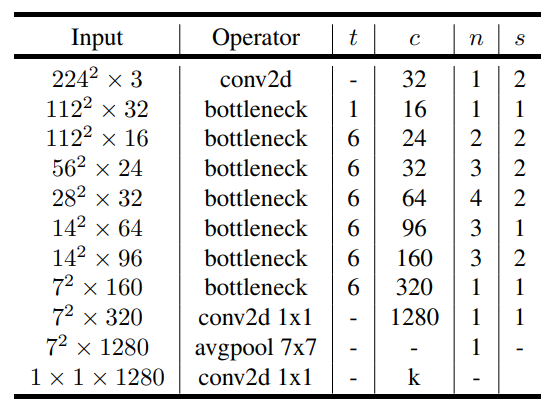

Let us implement the model and train it on both datasets.

In [28]:
class MobileNet_V2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU6(), 
            Linear_bottleneck(32, 16, stride = 1, expansion_factor = 1),
            
            Linear_bottleneck(16, 24, stride = 2, expansion_factor = 6),
            Inverted_residual_block(24, expansion_factor = 6),

            Linear_bottleneck(24, 32, stride = 2, expansion_factor = 6),
            Inverted_residual_block(32, expansion_factor = 6),
            Inverted_residual_block(32, expansion_factor = 6),

            Linear_bottleneck(32, 64, stride = 2, expansion_factor = 6),
            Inverted_residual_block(64, expansion_factor = 6),
            Inverted_residual_block(64, expansion_factor = 6),
            Inverted_residual_block(64, expansion_factor = 6),

            Linear_bottleneck(64, 96, stride = 1, expansion_factor = 6),
            Inverted_residual_block(96, expansion_factor = 6),
            Inverted_residual_block(96, expansion_factor = 6),

            Linear_bottleneck(96, 160, stride = 2, expansion_factor = 6),
            Inverted_residual_block(160, expansion_factor = 6),
            Inverted_residual_block(160, expansion_factor = 6),

            Linear_bottleneck(160, 320, stride = 1, expansion_factor = 6),

            nn.LazyConv2d(1280, kernel_size=3, stride=1, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU6(), 
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.LazyConv2d(num_classes, kernel_size=1),
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [29]:
layer_summary(MobileNet_V2(10),(1, 1, 128, 128))

Conv2d output shape:	 torch.Size([1, 32, 64, 64])
BatchNorm2d output shape:	 torch.Size([1, 32, 64, 64])
ReLU6 output shape:	 torch.Size([1, 32, 64, 64])
Linear_bottleneck output shape:	 torch.Size([1, 16, 64, 64])
Linear_bottleneck output shape:	 torch.Size([1, 24, 32, 32])
Inverted_residual_block output shape:	 torch.Size([1, 24, 32, 32])
Linear_bottleneck output shape:	 torch.Size([1, 32, 16, 16])
Inverted_residual_block output shape:	 torch.Size([1, 32, 16, 16])
Inverted_residual_block output shape:	 torch.Size([1, 32, 16, 16])
Linear_bottleneck output shape:	 torch.Size([1, 64, 8, 8])
Inverted_residual_block output shape:	 torch.Size([1, 64, 8, 8])
Inverted_residual_block output shape:	 torch.Size([1, 64, 8, 8])
Inverted_residual_block output shape:	 torch.Size([1, 64, 8, 8])
Linear_bottleneck output shape:	 torch.Size([1, 96, 8, 8])
Inverted_residual_block output shape:	 torch.Size([1, 96, 8, 8])
Inverted_residual_block output shape:	 torch.Size([1, 96, 8, 8])
Linear_bottleneck o

In [30]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [128, 128], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([128, 128]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)


fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# mobilenet initialization
MobileNet_cuda = MobileNet_V2(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
MobileNet_cuda(x);
MobileNet_cuda.apply(init_weights_he);

In terms of parameter count, MobileNet-V2 is twice the size of MobileNet.

In [31]:
sum(p.numel() for p in MobileNet_cuda.parameters() if p.requires_grad)

6170298

In [32]:
optim_SGD_cuda =  torch.optim.SGD(MobileNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, MobileNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1904.3168907165527


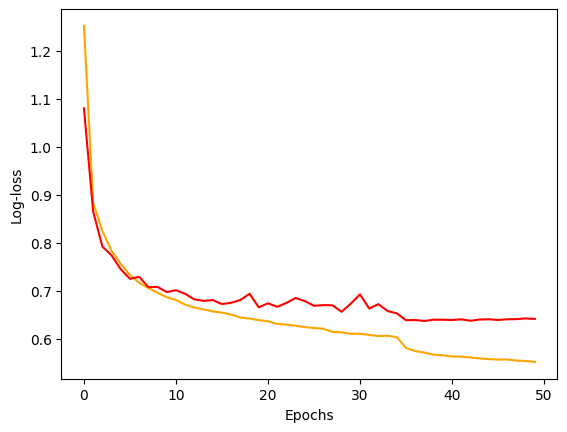

In [33]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

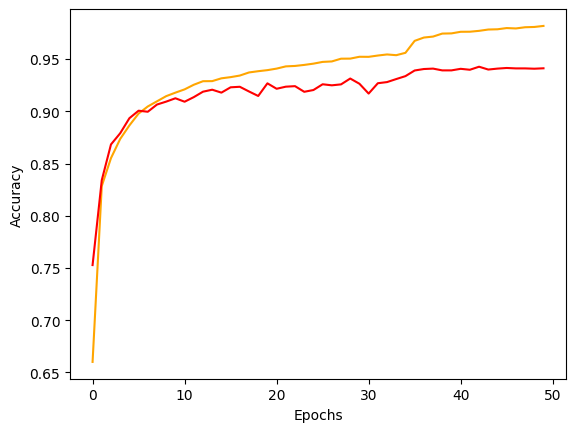

In [34]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

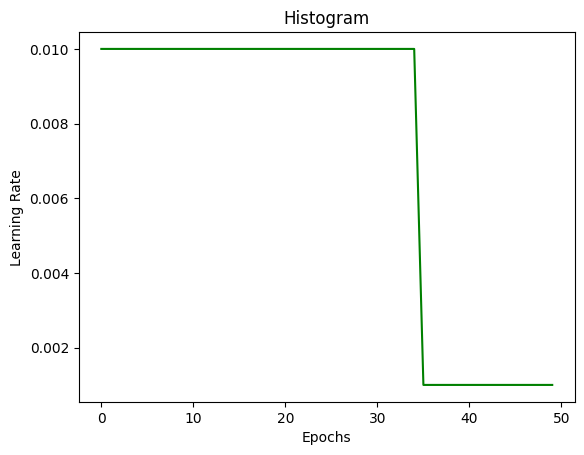

In [35]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [36]:
accu_epochs_train[49]

0.9817667007446289

In [37]:
accu_epochs_test[49]

0.9411999583244324

In [38]:
accu_epochs_test.max()

0.9426999688148499

The performance is slightly better than MobileNet.

In [39]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[128,128], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Resize([128, 128]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# mobilenet initialization
MobileNet_cuda = MobileNet_V2(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
MobileNet_cuda(x);
MobileNet_cuda.apply(init_weights_he);

In [40]:
optim_SGD_cuda =  torch.optim.SGD(MobileNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, MobileNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

8268.574193954468


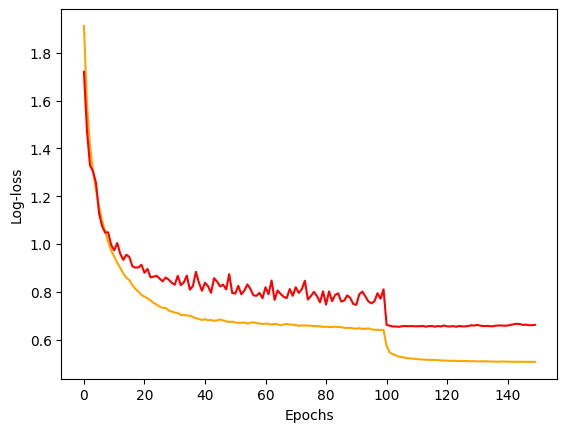

In [41]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

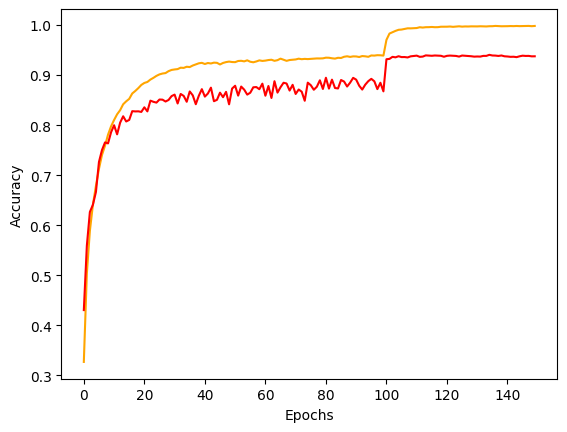

In [42]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [43]:
accu_epochs_train[149]

0.9982399940490723

In [44]:
accu_epochs_test[149]

0.9375999569892883

In [45]:
accu_epochs_test.max()

0.9404999613761902

Again, the performance is slightly better than MobileNet.

## MobileNet-V3 <a class="anchor" id="mobilenet3"></a>

MobileNet-V3 from 2019 [[3](#3)] is another take on the MobileNet architecture, adding a new element: the *squeeze-and-excitation* module proposed in [[5](#5)].

### Squeeze-and-Excitation <a class="anchor" id="squeeze"></a>

Squeeze-and-excitation adds to the CNN architecture the means to suppress certain features based on interdependencies among feature channels. Looking a bit ahead in our journey through neural network architectures, squeeze-and-excitation can be understood as a form of a self-attention mechanism, which is a prominent element of the transformer architecture [[6](#6)]. 

Squeeze-and-excitation is probably best understood from a figure.  Let us have a look at the following sketch [[5](#5)].

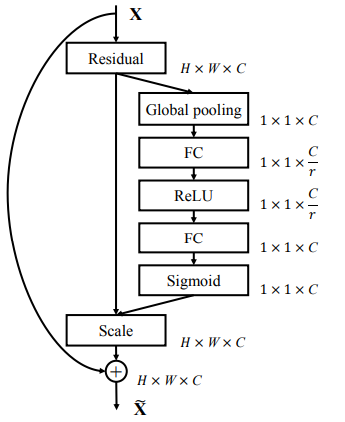

Here, *Residual* denotes a convolutional block (with a residual connection); its output is an image of size $H\times W\times C$. Let us denote it $X'$. We observe that before the original input is added to the output from the block *Residual* $X'$, the output $X'$ is transformed via a squeeze-and-excitation block. 

First, the $X'$ is *squeezed* to $1\times 1\times C$ by global average pooling. This step aims to extract simple *channel-wise* statistics. Next, two fully connected linear layers are applied (the first one further reduces the number of channels to $1\times 1\times C/r$). These linear layers aim to model the channel-wise dependencies. The output is a tensor of scales $S$ of $1\times 1\times C$ (the values are from $(0,1)$ due to the sigmoid activation function), which are used to rescale $X'$, i.e., the output after squeeze-and-excitation for the first channel $X'_1$ is $S_1X'_1$, where $S = [S_1, \ldots, S_C]$ [[5](#5)]. 

Squeeze-and-excitation can be used to augment any CNN architecture; the original paper focused on ResNet [[5](#5)]. Let us assume the following ResNet model, which we have used in the ResNet project.

In [46]:
class Residual_block(nn.Module):

    def __init__(self, num_channels, strides = 1,  conv1x1 = False):
        super().__init__()

        self.b1 = nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = 1), nn.LazyBatchNorm2d()
        )

        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels, kernel_size=1, stride = strides)
        else:
            self.b2 = None

    def forward(self, X):

        b1_x = self.b1(X)
        if self.b2:
            X = self.b2(X)
        b1_x += X

        return torch.nn.functional.relu(b1_x)

In [47]:
class ResNet_31(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block(128, strides = 1, conv1x1 = True),
            Residual_block(128),
            Residual_block(128),
            Residual_block(128),
            Residual_block(128),
            Residual_block(256, strides = 2, conv1x1 = True),
            Residual_block(256),
            Residual_block(256),
            Residual_block(256),
            Residual_block(256),
            Residual_block(512, strides = 2, conv1x1 = True),
            Residual_block(512),
            Residual_block(512),
            Residual_block(512),
            Residual_block(512),
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

Its performance on the CIFAR-10 dataset is as follows.

In [48]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_cuda = ResNet_31(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

7003.746951580048


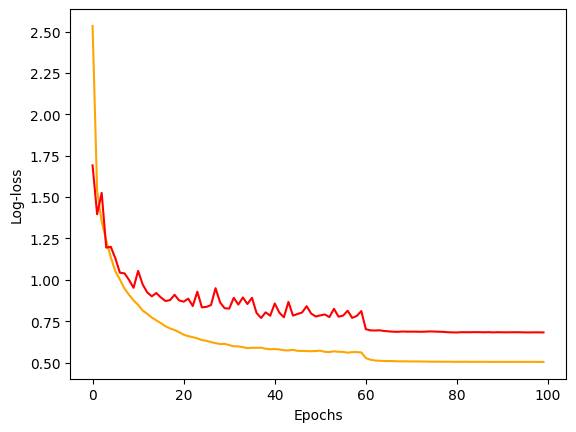

In [49]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

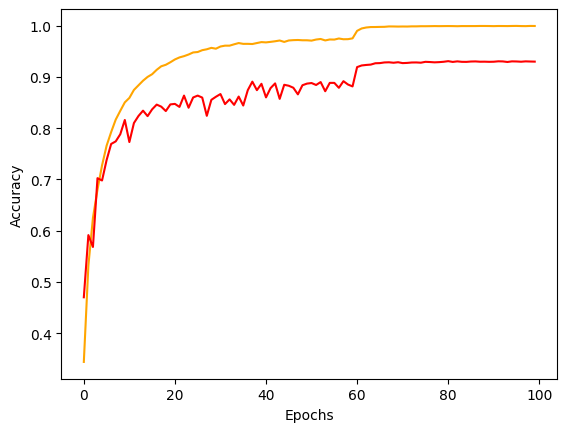

In [50]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [51]:
accu_epochs_train[99]

0.9995599985122681

In [52]:
accu_epochs_test[99]

0.9299999475479126

In [53]:
accu_epochs_test.max()

0.930899977684021

Let us now augment the residual blocks with squeeze-and-excitation (implemented in PyTorch as *torchvision.ops.SqueezeExcitation*). Note that we follow the MobileNet-V3 implementation of squeeze-and-excitation [[3](#3)], using the hard sigmoid activation instead of the sigmoid.  
$$ \text{Hardsigmoid}(x) = \begin{cases}
0 & \text{if } x \leq -3\\
1 & \text{if } x \geq 3 \\
x/6 + 1/2 & \text{otherwise}
\end{cases}$$
We should also note that *squeeze_channels* equals $C/r$ in our sketch of squeeze-and-excitation.

In [54]:
class Residual_block_SE(nn.Module):

    def __init__(self, num_channels, strides = 1,  conv1x1 = False):
        super().__init__()

        self.b1 = nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = 1), nn.LazyBatchNorm2d(),
                                torchvision.ops.SqueezeExcitation(input_channels = num_channels, squeeze_channels = num_channels//4, scale_activation=nn.Hardsigmoid),
        )
        
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels, kernel_size=1, stride = strides)
        else:
            self.b2 = None

    def forward(self, X):

        b1_x = self.b1(X)
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

In [55]:
class ResNet_31(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block_SE(128, strides = 1, conv1x1 = True),
            Residual_block_SE(128),
            Residual_block_SE(128),
            Residual_block_SE(128),
            Residual_block_SE(128),
            Residual_block_SE(256, strides = 2, conv1x1 = True),
            Residual_block_SE(256),
            Residual_block_SE(256),
            Residual_block_SE(256),
            Residual_block_SE(256),
            Residual_block_SE(512, strides = 2, conv1x1 = True),
            Residual_block_SE(512),
            Residual_block_SE(512),
            Residual_block_SE(512),
            Residual_block_SE(512),
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [56]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_cuda = ResNet_31(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

7824.951603889465


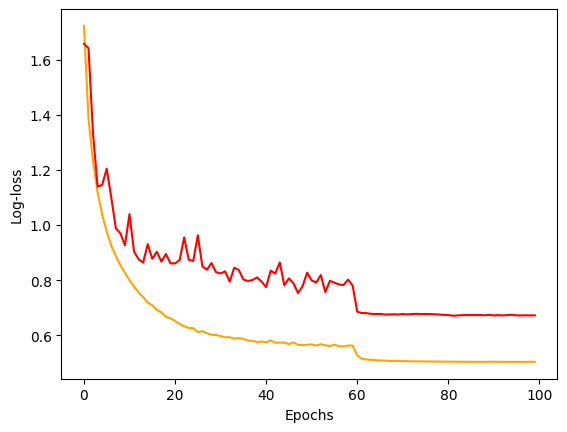

In [57]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

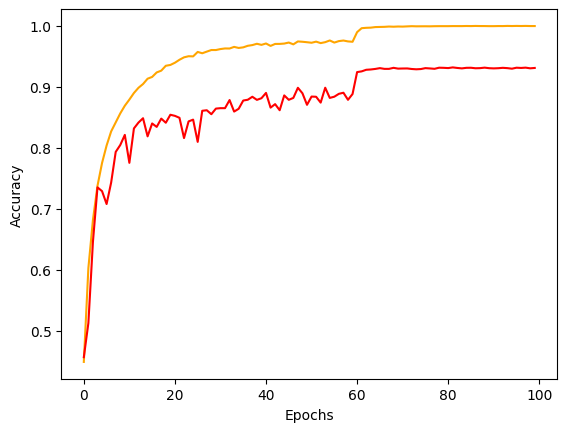

In [58]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [59]:
accu_epochs_train[99]

0.9994799494743347

In [60]:
accu_epochs_test[99]

0.9307999610900879

In [61]:
accu_epochs_test.max()

0.9316999912261963

We observe a minor improvement in performance over ResNet-31.

### MobileNet-V3 <a class="anchor" id="mobilenet3_2"></a>

MobileNet-V3 uses inverted residual blocks and linear bottlenecks from MobileNet-V2 augmented with squeeze-and-excitation [[3](#3)].

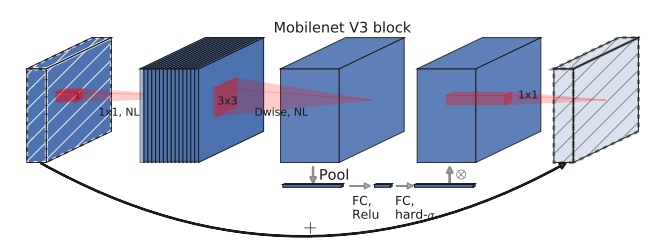

In [62]:
class MobileNetV3_Depthwise_convolution(nn.Module):

    def __init__(self, num_channels, kernel_size, padding, stride):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(num_channels, kernel_size = kernel_size, stride = stride, padding = padding, groups = num_channels), 
        )
            
    def forward(self, x):
        output = self.net_stack(x)
        return output

In [63]:
class MobileNetV3_inverted_residual_block_noSE(nn.Module):
    
    def __init__(self, num_channels, expansion, kernel_size, padding, nln): # in_channels == out_channels and stride = 1 for an inverted residual block!
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(expansion, kernel_size=1),  nn.LazyBatchNorm2d(), nln,
            MobileNetV3_Depthwise_convolution(expansion, kernel_size = kernel_size, stride = 1, padding = padding), nn.LazyBatchNorm2d(), nln,
            nn.LazyConv2d(num_channels, kernel_size=1), nn.LazyBatchNorm2d()
        )
    
    def forward(self, x):
        y = self.net_stack(x)
        return y + x   

In [64]:
class MobileNetV3_linear_bottleneck_noSE(nn.Module):
    
    def __init__(self, num_channels, expansion, kernel_size, stride, padding,  nln):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(expansion, kernel_size=1),  nn.LazyBatchNorm2d(), nln,
            MobileNetV3_Depthwise_convolution(expansion, kernel_size = kernel_size, stride = stride, padding = padding), nn.LazyBatchNorm2d(), nln,
            nn.LazyConv2d(num_channels, kernel_size=1), nn.LazyBatchNorm2d()
        )

    def forward(self, x):
        y = self.net_stack(x)
        return y

In [65]:
class MobileNetV3_inverted_residual_block_SE(nn.Module):
    
    def __init__(self, num_channels, expansion, kernel_size, padding, nln): # in_channels == out_channels and stride = 1 for an inverted residual block!
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(expansion, kernel_size=1),  nn.LazyBatchNorm2d(), nln,
            MobileNetV3_Depthwise_convolution(expansion, kernel_size = kernel_size, stride = 1, padding = padding), nn.LazyBatchNorm2d(), nln,
            torchvision.ops.SqueezeExcitation(input_channels = expansion, squeeze_channels = expansion//4, scale_activation=nn.Hardsigmoid),
            nn.LazyConv2d(num_channels, kernel_size=1), nn.LazyBatchNorm2d()
        )
    
    def forward(self, x):
        y = self.net_stack(x)
        return y + x     

In [66]:
class MobileNetV3_linear_bottleneck_SE(nn.Module):
    
    def __init__(self, num_channels, expansion, kernel_size, stride, padding, nln):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(expansion, kernel_size=1),  nn.LazyBatchNorm2d(), nln,
            MobileNetV3_Depthwise_convolution(expansion, kernel_size = kernel_size, stride = stride, padding = padding), nn.LazyBatchNorm2d(), nln,
            torchvision.ops.SqueezeExcitation(expansion, squeeze_channels = expansion//4, scale_activation = nn.Hardsigmoid),
            nn.LazyConv2d(num_channels, kernel_size=1), nn.LazyBatchNorm2d()
        )

    def forward(self, x):
        y = self.net_stack(x)
        return y

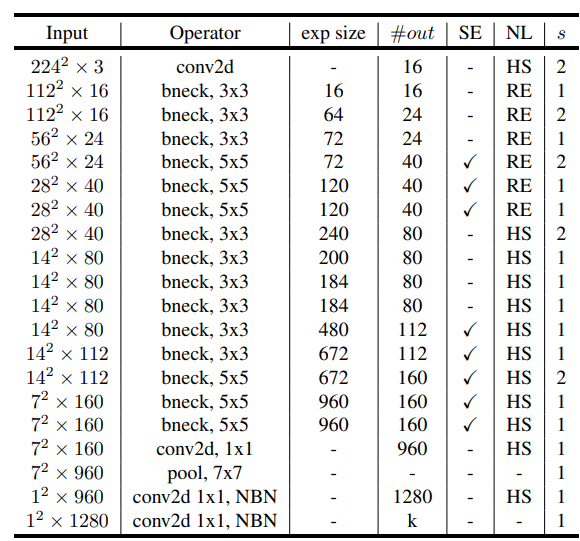

In addition, MobileNet-V3 uses some convolution layers with 5x5 kernels. We also notice that some layers use the HardSwish activation instead of ReLU.
$$ \text{Hardswish}(x) = \begin{cases}
0 & \text{if } x \leq -3\\
x & \text{if } x \geq 3 \\
x(x+3)/6 & \text{otherwise}
\end{cases}$$

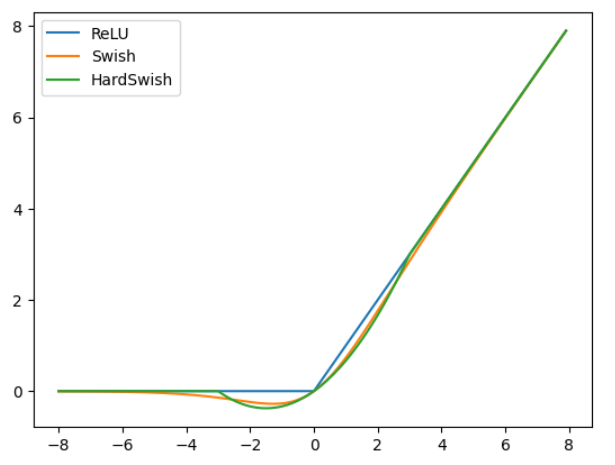

Unlike ReLU, Hard-Swish (and Swish $x\sigma(x)$) are non-zero for small negative values, making it less likely that some neurons die during training. Hard-Swish is used in MobileNet-V3 instead of Swish to reduce computational complexity (sigmoid function $\sigma(x)$ requires evaluating exponentials).

In [67]:
class MobileNet_V3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(16, kernel_size=3, stride=2, padding=1),  nn.LazyBatchNorm2d(), nn.Hardswish(), 

            MobileNetV3_inverted_residual_block_noSE(16, expansion = 16, kernel_size = 3, padding = 1, nln = nn.ReLU()),
            
            MobileNetV3_linear_bottleneck_noSE(24, expansion = 64, kernel_size = 3, stride = 2, padding = 1, nln = nn.ReLU()),
            MobileNetV3_inverted_residual_block_noSE(24, expansion = 72, kernel_size = 3, padding = 1, nln = nn.ReLU()),

            MobileNetV3_linear_bottleneck_SE(40, expansion = 72, kernel_size = 5, stride = 2, padding = 2, nln = nn.ReLU()),
            MobileNetV3_inverted_residual_block_SE(40, expansion = 120, kernel_size = 5, padding = 2, nln = nn.ReLU()),
            MobileNetV3_inverted_residual_block_SE(40, expansion = 120, kernel_size = 5, padding = 2, nln = nn.ReLU()),

            MobileNetV3_linear_bottleneck_noSE(80, expansion = 240, kernel_size = 3, stride = 2, padding = 1, nln = nn.Hardswish()),
            MobileNetV3_inverted_residual_block_noSE(80, expansion = 200, kernel_size = 3, padding = 1, nln = nn.Hardswish()),
            MobileNetV3_inverted_residual_block_noSE(80, expansion = 184, kernel_size = 3, padding = 1, nln = nn.Hardswish()),
            MobileNetV3_inverted_residual_block_noSE(80, expansion = 184, kernel_size = 3, padding = 1, nln = nn.Hardswish()),

            MobileNetV3_linear_bottleneck_SE(112, expansion = 480, kernel_size = 3, stride = 1, padding = 1, nln = nn.Hardswish()),
            MobileNetV3_inverted_residual_block_SE(112, expansion = 672, kernel_size = 3, padding = 1, nln = nn.Hardswish()),

            MobileNetV3_linear_bottleneck_SE(160, expansion = 672, kernel_size = 5, stride = 2, padding = 2, nln = nn.Hardswish()),
            MobileNetV3_inverted_residual_block_SE(160, expansion = 960, kernel_size = 5, padding = 2, nln = nn.Hardswish()),
            MobileNetV3_inverted_residual_block_SE(160, expansion = 960, kernel_size = 5, padding = 2, nln = nn.Hardswish()),

            nn.LazyConv2d(960, kernel_size=1),  nn.LazyBatchNorm2d(), nn.Hardswish(),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.LazyConv2d(1280, kernel_size=1), nn.Hardswish(),
            nn.LazyConv2d(num_classes, kernel_size=1),
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [68]:
layer_summary(MobileNet_V3(10),(1, 1, 128, 128))

Conv2d output shape:	 torch.Size([1, 16, 64, 64])
BatchNorm2d output shape:	 torch.Size([1, 16, 64, 64])
Hardswish output shape:	 torch.Size([1, 16, 64, 64])
MobileNetV3_inverted_residual_block_noSE output shape:	 torch.Size([1, 16, 64, 64])
MobileNetV3_linear_bottleneck_noSE output shape:	 torch.Size([1, 24, 32, 32])
MobileNetV3_inverted_residual_block_noSE output shape:	 torch.Size([1, 24, 32, 32])
MobileNetV3_linear_bottleneck_SE output shape:	 torch.Size([1, 40, 16, 16])
MobileNetV3_inverted_residual_block_SE output shape:	 torch.Size([1, 40, 16, 16])
MobileNetV3_inverted_residual_block_SE output shape:	 torch.Size([1, 40, 16, 16])
MobileNetV3_linear_bottleneck_noSE output shape:	 torch.Size([1, 80, 8, 8])
MobileNetV3_inverted_residual_block_noSE output shape:	 torch.Size([1, 80, 8, 8])
MobileNetV3_inverted_residual_block_noSE output shape:	 torch.Size([1, 80, 8, 8])
MobileNetV3_inverted_residual_block_noSE output shape:	 torch.Size([1, 80, 8, 8])
MobileNetV3_linear_bottleneck_SE o

In [69]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [128, 128], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([128, 128]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)


fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# mobilenet initialization
MobileNet_cuda = MobileNet_V3(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
MobileNet_cuda(x);
MobileNet_cuda.apply(init_weights_he);

In [70]:
sum(p.numel() for p in MobileNet_cuda.parameters() if p.requires_grad)

4225224

In [71]:
optim_SGD_cuda =  torch.optim.SGD(MobileNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, MobileNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1947.3233766555786


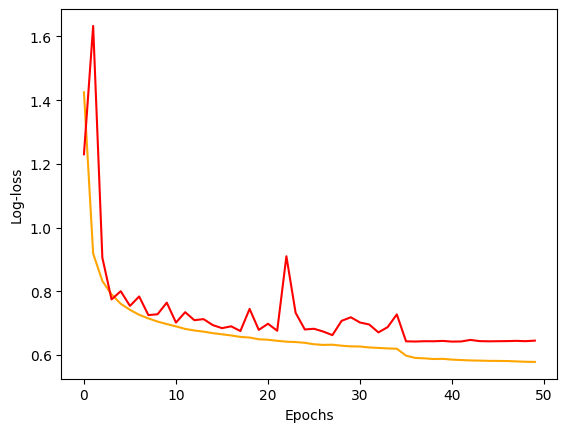

In [72]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

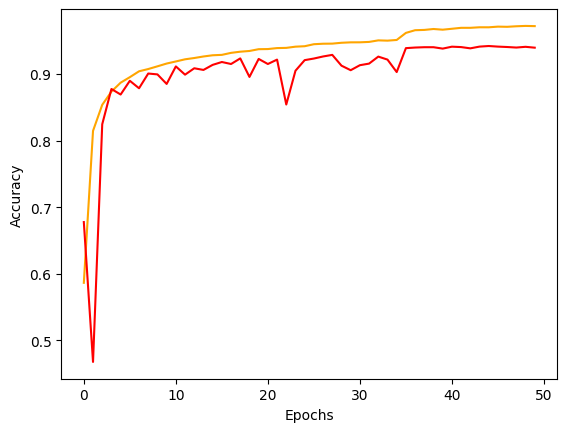

In [73]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [74]:
accu_epochs_train[49]

0.971750020980835

In [75]:
accu_epochs_test[49]

0.9393999576568604

In [76]:
accu_epochs_test.max()

0.9418999552726746

The performance on Fashion-MNIST is similar to MobileNet and MobileNet-V2.

In [77]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[128,128], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Resize([128, 128]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# mobilenet initialization
MobileNet_cuda = MobileNet_V3(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
MobileNet_cuda(x);
MobileNet_cuda.apply(init_weights_he);

In [78]:
optim_SGD_cuda =  torch.optim.SGD(MobileNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, MobileNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

8663.350872278214


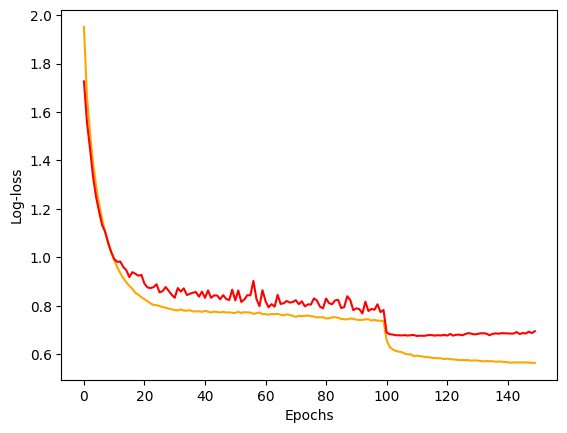

In [79]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

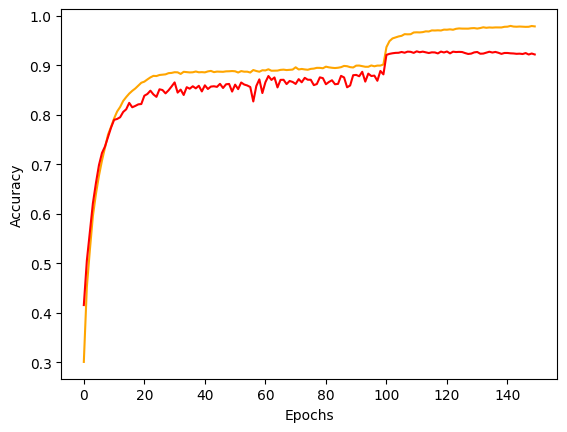

In [80]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [81]:
accu_epochs_train[149]

0.9782199859619141

In [82]:
accu_epochs_test[149]

0.9215999841690063

In [83]:
accu_epochs_test.max()

0.927899956703186

We achieve a worse result with MobileNet-V3 than with MobileNet and MobileNet-V2 on the CIFAR-10 dataset.

We should note here that, despite what our little experiment might suggest, MobilNet-V3 achieved top performance on the ImageNet dataset relative to its size [[3](#3)]. In addition, as we will see in the next project, MobilNet-V3 served as the basis for *EfficientNet*, which achieved state-of-the-art accuracy on the ImageNet dataset at the time despite being almost 10x smaller than other CNNs. Lastly, we should mention the increasingly prevalent paradigm shift in model training at the time. 

Up to this point, we have employed a standard approach of designing a specific neural network architecture for a given dataset and training it on that dataset. However, it turns out that one can often obtain comparable or even better performance by using a pretrained model on a related large dataset (such as ImageNet-1K) and then merely *fine-tune* it for the given task (e.g., classification on the CIFAR-10 dataset). The approach of using a pretrained model in a new context is known as *transfer learning*, and it allows us to train large, powerful models on small datasets [[7](#7), [8](#8), [9](#9)]. 

Consequently, it does not matter as much that some modern CNNs did not perform well for us when trained on CIFAR-10 *from scratch* (Inception-ResNet, Xception, and MobileNet-V3 come to mind), since we can always fine-tune them from the pretrained weights instead. We will demonstrate this in the next project.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> HOWARD, Andrew G., et al. MobileNets: Efficient convolutional neural networks for mobile vision applications. *arXiv preprint arXiv:1704.04861*, 2017.

<a id="2">[2]</a> SANDLER, Mark, et al. MobileNetv2: Inverted residuals and linear bottlenecks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2018. p. 4510-4520.

<a id="3">[3]</a> HOWARD, Andrew, et al. Searching for mobilenetv3. In: *Proceedings of the IEEE/CVF International conference on computer vision.* 2019. p. 1314-1324.

<a id="4">[4]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms. *arXiv preprint arXiv:1708.07747*, 2017.

<a id="5">[5]</a> HU, Jie; SHEN, Li; SUN, Gang. Squeeze-and-excitation networks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2018. p. 7132-7141.

<a id="6">[6]</a> VASWANI, Ashish, et al. Attention is all you need. *Advances in neural information processing systems*, 2017, 30.

<a id="7">[7]</a> HUH, Minyoung; AGRAWAL, Pulkit; EFROS, Alexei A. What makes ImageNet good for transfer learning?. *arXiv preprint arXiv:1608.08614,* 2016.

<a id="8">[8]</a> RUDER, Sebastian. Transfer Learning - Machine Learning's Next Frontier. *http://ruder.io/transfer-learning/*, 2017.

<a id="9">[9]</a> KORNBLITH, Simon; SHLENS, Jonathon; LE, Quoc V. Do better Imagenet models transfer better?. In: *Proceedings of the IEEE/CVF conference on computer vision and pattern recognition.* 2019. p. 2661-2671.